In [1]:
%run stochastic_lite.ipynb

In [2]:
deltaF=0.25
segmentDuration=64

## Noise only

In [28]:
dat=np.load('data/colored_noise_H1.npy')
t1,h1=dat[:,0],dat[:,1]
d1=TimeSeries(t1,h1)

dat=np.load('data/colored_noise_H2.npy')
t2,h2=dat[:,0],dat[:,1]
d2=TimeSeries(t2,h2)

jobDuration=d2.times[-1]-d2.times[0]+d2.deltaT

In [29]:
nperseg=int(d1.Fs/deltaF)
freqs,P1_test = welch_psd(d1.data,nperseg=nperseg,window='Hann',fs=d1.Fs)
freqs,P2_test = welch_psd(d2.data,nperseg=nperseg,window='Hann',fs=d2.Fs)

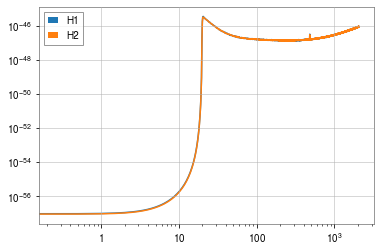

In [30]:
plt.loglog(freqs,P1_test,label='H1')
plt.loglog(freqs,P2_test,label='H2')
plt.legend()

In [31]:
Ys,sigs,Y_fs,var_fs,segmentStartTimes,freqs=stochastic(d1,
                                                       d2,
                                                       segmentDuration,
                                                       deltaF,
                                                       verbose=False,
                                                       doOverlap=True,
                                                       alpha=0,
                                                       fref=25,
                                                       orf_file=None)

/Users/andrewmatas/.local/lib/python3.7/site-packages/ipykernel_launcher.py:106: RuntimeWarning: divide by zero encountered in power
/Users/andrewmatas/.local/lib/python3.7/site-packages/ipykernel_launcher.py:114: ComplexWarning: Casting complex values to real discards the imaginary part
/Users/andrewmatas/.local/lib/python3.7/site-packages/ipykernel_launcher.py:115: ComplexWarning: Casting complex values to real discards the imaginary part


In [32]:
# combine spectra over times

Y_f,var_f=postprocessing_spectra(Y_fs,var_fs,jobDuration,segmentDuration,
                                 deltaF,d1.deltaT)

/Users/andrewmatas/.local/lib/python3.7/site-packages/ipykernel_launcher.py:14: RuntimeWarning: invalid value encountered in true_divide
  
/Users/andrewmatas/.local/lib/python3.7/site-packages/ipykernel_launcher.py:15: RuntimeWarning: divide by zero encountered in true_divide
  from ipykernel import kernelapp as app
/Users/andrewmatas/.local/lib/python3.7/site-packages/ipykernel_launcher.py:17: RuntimeWarning: invalid value encountered in true_divide
/Users/andrewmatas/.local/lib/python3.7/site-packages/ipykernel_launcher.py:18: RuntimeWarning: divide by zero encountered in true_divide
/Users/andrewmatas/.local/lib/python3.7/site-packages/ipykernel_launcher.py:28: RuntimeWarning: invalid value encountered in subtract
/Users/andrewmatas/.local/lib/python3.7/site-packages/ipykernel_launcher.py:30: RuntimeWarning: invalid value encountered in subtract
/Users/andrewmatas/.local/lib/python3.7/site-packages/ipykernel_launcher.py:31: RuntimeWarning: invalid value encountered in subtract


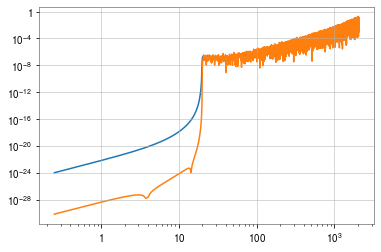

In [33]:
plt.loglog(freqs,np.sqrt(var_f))
plt.loglog(freqs,np.abs(Y_f))

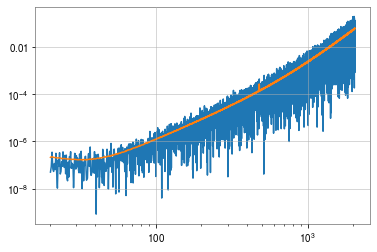

In [34]:
f_filter=freqs>20

plt.loglog(freqs[f_filter],np.abs(Y_f[f_filter]))
plt.loglog(freqs[f_filter],np.sqrt(var_f[f_filter]))


In [35]:
# compute optimal SNR

y,s=calc_Y_sigma_from_Yf_varf(np.real(Y_f[f_filter]),
                          var_f[f_filter],
                          freqs=freqs[f_filter],
                          alpha=2./3,
                          fref=25)

print('Optimal SNR [alpha=2/3]: %f'%(y/s))

Optimal SNR [alpha=2/3]: 0.135548


Text(0, 0.5, 'SNR')

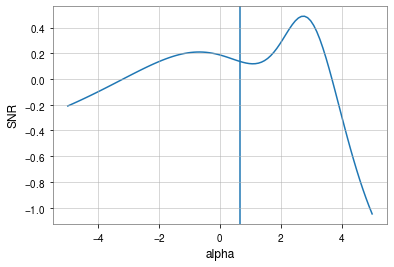

In [36]:
alphas=np.linspace(-5,5,100)

snrs=np.zeros(alphas.shape)
for ii,a in enumerate(alphas):
    y,s=calc_Y_sigma_from_Yf_varf(np.real(Y_f[f_filter]),
                          var_f[f_filter],
                          freqs=freqs[f_filter],
                          alpha=a,
                          fref=25)
    snrs[ii]=y/s
plt.plot(alphas,snrs)
plt.axvline(2./3)
plt.xlabel('alpha')
plt.ylabel('SNR')

17:06 bilby INFO    : Running for label 'GWB_powerlaw', output will be saved to 'outdir'
17:06 bilby INFO    : Search parameters:
17:06 bilby INFO    :   A = LogUniform(minimum=1e-08, maximum=0.001, name='A', latex_label='A', unit=None, boundary=None)
17:06 bilby INFO    :   alpha = Uniform(minimum=-5, maximum=5, name='alpha', latex_label='alpha', unit=None, boundary=None)
17:06 bilby INFO    : Single likelihood evaluation took 4.516e-04 s


0it [00:00, ?it/s]

17:06 bilby INFO    : Using sampler Dynesty with kwargs {'bound': 'multi', 'sample': 'rwalk', 'verbose': True, 'periodic': None, 'reflective': None, 'check_point_delta_t': 600, 'nlive': 500, 'first_update': None, 'walks': 10, 'npdim': None, 'rstate': None, 'queue_size': None, 'pool': None, 'use_pool': None, 'live_points': None, 'logl_args': None, 'logl_kwargs': None, 'ptform_args': None, 'ptform_kwargs': None, 'enlarge': 1.5, 'bootstrap': None, 'vol_dec': 0.5, 'vol_check': 8.0, 'facc': 0.2, 'slices': 5, 'update_interval': 300, 'print_func': <bound method Dynesty._print_func of <bilby.core.sampler.dynesty.Dynesty object at 0x7ff2422126d0>>, 'dlogz': 0.1, 'maxiter': None, 'maxcall': None, 'logl_max': inf, 'add_live': True, 'print_progress': True, 'save_bounds': False, 'n_effective': None, 'maxmcmc': 10000, 'nact': 5}
17:06 bilby INFO    : Checkpoint every n_check_point = 1000000
17:06 bilby INFO    : Using dynesty version 1.0.1
17:06 bilby INFO    : Using the bilby-implemented rwalk samp

2709it [00:36, 34.72it/s, bound:108 nc:49 ncall:52024 eff:5.2% logz-ratio=-3.18+/-nan dlogz:0.101>0.10]      

17:06 bilby INFO    : Writing checkpoint file outdir/GWB_powerlaw_resume.pickle



2711it [00:37, 72.87it/s, bound:108 nc:1 ncall:52102 eff:6.2% logz-ratio=-3.08+/-nan dlogz:0.000>0.10] 



17:06 bilby INFO    : Sampling time: 0:00:36.021490
17:06 bilby INFO    : Summary of results:
nsamples: 3211
log_noise_evidence: 42845.346
log_evidence: 42842.266 +/-    nan
log_bayes_factor: -3.080 +/-    nan



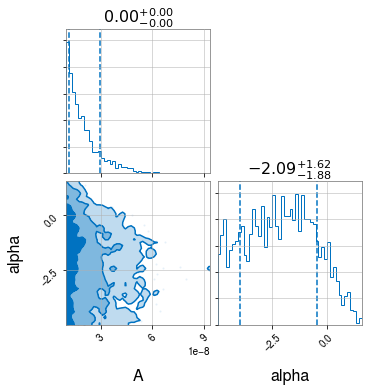

In [37]:
# A few simple setup steps
label = 'GWB_powerlaw'
outdir = 'outdir'

cleanup(outdir)

Amin,Amax,alpha_min,alpha_max=1e-8,1e-3,-5,5
    

fref=25

likelihood = BasicPowerLawGWBLikelihood(Y_f[f_filter],var_f[f_filter],freqs[f_filter],fref)
priors = dict(A=bilby.core.prior.LogUniform(Amin,Amax, 'A'),
              alpha=bilby.core.prior.Uniform(alpha_min,alpha_max, 'alpha'))

# And run sampler
result = bilby.run_sampler(
    likelihood=likelihood, priors=priors, sampler='dynesty', npoints=500,
    walks=10, outdir=outdir, label=label,maxmcmc=10000)
result.plot_corner()

## Noise + CBCs


In [13]:
dat=np.load('data/colored_noise_plus_signal_H1.npy')
t1,h1=dat[:,0],dat[:,1]
d1=TimeSeries(t1,h1)

dat=np.load('data/colored_noise_plus_signal_H2.npy')
t2,h2=dat[:,0],dat[:,1]
d2=TimeSeries(t2,h2)

jobDuration=d2.times[-1]-d2.times[0]+d2.deltaT

In [14]:
nperseg=int(d1.Fs/deltaF)
freqs,P1_test = welch_psd(d1.data,nperseg=nperseg,window='Hann',fs=d1.Fs)
freqs,P2_test = welch_psd(d2.data,nperseg=nperseg,window='Hann',fs=d2.Fs)

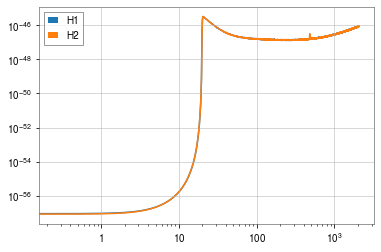

In [15]:
plt.loglog(freqs,P1_test,label='H1')
plt.loglog(freqs,P2_test,label='H2')
plt.legend()

In [17]:
Ys,sigs,Y_fs,var_fs,segmentStartTimes,freqs=stochastic(d1,
                                                       d2,
                                                       segmentDuration,
                                                       deltaF,
                                                       verbose=False,
                                                       doOverlap=True,
                                                       alpha=0,
                                                       fref=25,
                                                       orf_file=None)

/Users/andrewmatas/.local/lib/python3.7/site-packages/ipykernel_launcher.py:106: RuntimeWarning: divide by zero encountered in power
/Users/andrewmatas/.local/lib/python3.7/site-packages/ipykernel_launcher.py:114: ComplexWarning: Casting complex values to real discards the imaginary part
/Users/andrewmatas/.local/lib/python3.7/site-packages/ipykernel_launcher.py:115: ComplexWarning: Casting complex values to real discards the imaginary part


In [18]:
# combine spectra over times

Y_f,var_f=postprocessing_spectra(Y_fs,var_fs,jobDuration,segmentDuration,
                                 deltaF,d1.deltaT)

/Users/andrewmatas/.local/lib/python3.7/site-packages/ipykernel_launcher.py:14: RuntimeWarning: invalid value encountered in true_divide
  
/Users/andrewmatas/.local/lib/python3.7/site-packages/ipykernel_launcher.py:15: RuntimeWarning: divide by zero encountered in true_divide
  from ipykernel import kernelapp as app
/Users/andrewmatas/.local/lib/python3.7/site-packages/ipykernel_launcher.py:17: RuntimeWarning: invalid value encountered in true_divide
/Users/andrewmatas/.local/lib/python3.7/site-packages/ipykernel_launcher.py:18: RuntimeWarning: divide by zero encountered in true_divide
/Users/andrewmatas/.local/lib/python3.7/site-packages/ipykernel_launcher.py:28: RuntimeWarning: invalid value encountered in subtract
/Users/andrewmatas/.local/lib/python3.7/site-packages/ipykernel_launcher.py:30: RuntimeWarning: invalid value encountered in subtract
/Users/andrewmatas/.local/lib/python3.7/site-packages/ipykernel_launcher.py:31: RuntimeWarning: invalid value encountered in subtract


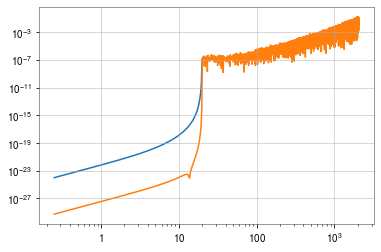

In [19]:
plt.loglog(freqs,np.sqrt(var_f))
plt.loglog(freqs,np.abs(Y_f))

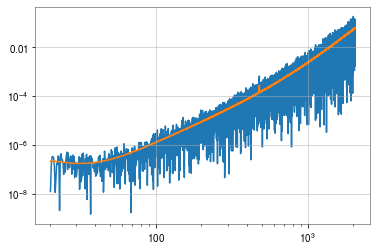

In [20]:
f_filter=freqs>20

plt.loglog(freqs[f_filter],np.abs(Y_f[f_filter]))
plt.loglog(freqs[f_filter],np.sqrt(var_f[f_filter]))


In [21]:
-0.5*(len(freqs[f_filter]))

-4055.5

In [22]:
# compute optimal SNR

y,s=calc_Y_sigma_from_Yf_varf(np.real(Y_f[f_filter]),
                          var_f[f_filter],
                          freqs=freqs[f_filter],
                          alpha=2./3,
                          fref=25)

print('Optimal SNR [alpha=2/3]: %f'%(y/s))


Optimal SNR [alpha=2/3]: 4.564919


Text(0, 0.5, 'SNR')

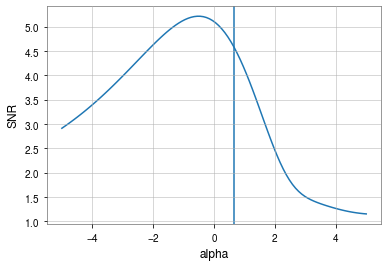

In [23]:
alphas=np.linspace(-5,5,100)

snrs=np.zeros(alphas.shape)
for ii,a in enumerate(alphas):
    y,s=calc_Y_sigma_from_Yf_varf(np.real(Y_f[f_filter]),
                          var_f[f_filter],
                          freqs=freqs[f_filter],
                          alpha=a,
                          fref=25)
    snrs[ii]=y/s
plt.plot(alphas,snrs)
plt.axvline(2./3)
plt.xlabel('alpha')
plt.ylabel('SNR')

17:04 bilby INFO    : Running for label 'GWB_powerlaw', output will be saved to 'outdir'
17:04 bilby INFO    : Search parameters:
17:04 bilby INFO    :   A = LogUniform(minimum=1e-08, maximum=0.001, name='A', latex_label='A', unit=None, boundary=None)
17:04 bilby INFO    :   alpha = Uniform(minimum=-5, maximum=5, name='alpha', latex_label='alpha', unit=None, boundary=None)
17:04 bilby INFO    : Single likelihood evaluation took 4.790e-04 s


0it [00:00, ?it/s]

17:04 bilby INFO    : Using sampler Dynesty with kwargs {'bound': 'multi', 'sample': 'rwalk', 'verbose': True, 'periodic': None, 'reflective': None, 'check_point_delta_t': 600, 'nlive': 500, 'first_update': None, 'walks': 10, 'npdim': None, 'rstate': None, 'queue_size': None, 'pool': None, 'use_pool': None, 'live_points': None, 'logl_args': None, 'logl_kwargs': None, 'ptform_args': None, 'ptform_kwargs': None, 'enlarge': 1.5, 'bootstrap': None, 'vol_dec': 0.5, 'vol_check': 8.0, 'facc': 0.2, 'slices': 5, 'update_interval': 300, 'print_func': <bound method Dynesty._print_func of <bilby.core.sampler.dynesty.Dynesty object at 0x7ff251c8c3d0>>, 'dlogz': 0.1, 'maxiter': None, 'maxcall': None, 'logl_max': inf, 'add_live': True, 'print_progress': True, 'save_bounds': False, 'n_effective': None, 'maxmcmc': 10000, 'nact': 5}
17:04 bilby INFO    : Checkpoint every n_check_point = 1000000
17:04 bilby INFO    : Using dynesty version 1.0.1
17:04 bilby INFO    : Using the bilby-implemented rwalk samp

3728it [01:21, 27.70it/s, bound:318 nc:59 ncall:118021 eff:3.2% logz-ratio=8.40+/-0.62 dlogz:0.100>0.10]     

17:05 bilby INFO    : Writing checkpoint file outdir/GWB_powerlaw_resume.pickle



3729it [01:22, 45.30it/s, bound:318 nc:1 ncall:118074 eff:3.6% logz-ratio=8.49+/-0.62 dlogz:0.000>0.10] 



17:05 bilby INFO    : Sampling time: 0:01:21.024630
17:05 bilby INFO    : Summary of results:
nsamples: 4229
log_noise_evidence: 42857.083
log_evidence: 42865.576 +/-  0.619
log_bayes_factor:  8.492 +/-  0.619



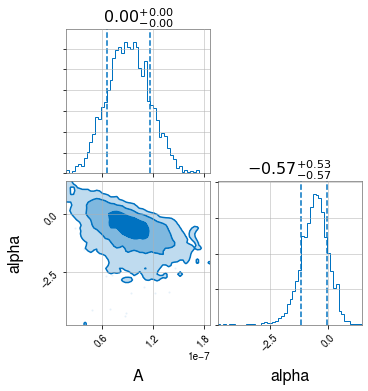

In [24]:
# A few simple setup steps
label = 'GWB_powerlaw'
outdir = 'outdir'

cleanup(outdir)

Amin,Amax,alpha_min,alpha_max=1e-8,1e-3,-5,5
    

fref=25

likelihood = BasicPowerLawGWBLikelihood(Y_f[f_filter],var_f[f_filter],freqs[f_filter],fref)
priors = dict(A=bilby.core.prior.LogUniform(Amin,Amax, 'A'),
              alpha=bilby.core.prior.Uniform(alpha_min,alpha_max, 'alpha'))

# And run sampler
result = bilby.run_sampler(
    likelihood=likelihood, priors=priors, sampler='dynesty', npoints=500,
    walks=10, outdir=outdir, label=label,maxmcmc=10000)
result.plot_corner()

In [25]:
A=result.samples[:,0]
alpha=result.samples[:,1]

Text(0.5, 0, '')

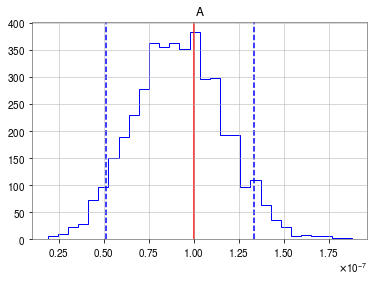

In [26]:
plt.hist(A,bins=30,histtype='step',color='blue')
plt.axvline(np.percentile(A,5),color='blue',linestyle='--')
plt.axvline(np.percentile(A,95),color='blue',linestyle='--')

plt.axvline(1e-7,color='red')

plt.title('A')
plt.xlabel('')

Text(0.5, 0, '')

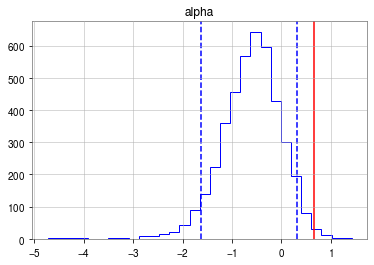

In [27]:
plt.hist(alpha,bins=30,histtype='step',color='blue')
plt.axvline(np.percentile(alpha,5),color='blue',linestyle='--')
plt.axvline(np.percentile(alpha,95),color='blue',linestyle='--')

plt.axvline(2./3,color='red')

plt.title('alpha')
plt.xlabel('')